<a href="https://colab.research.google.com/github/ben854719/ModSense-AI-Powered-Community-Health-Moderation-Intelligence/blob/main/Reddit_Community_Health_and_Safety_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

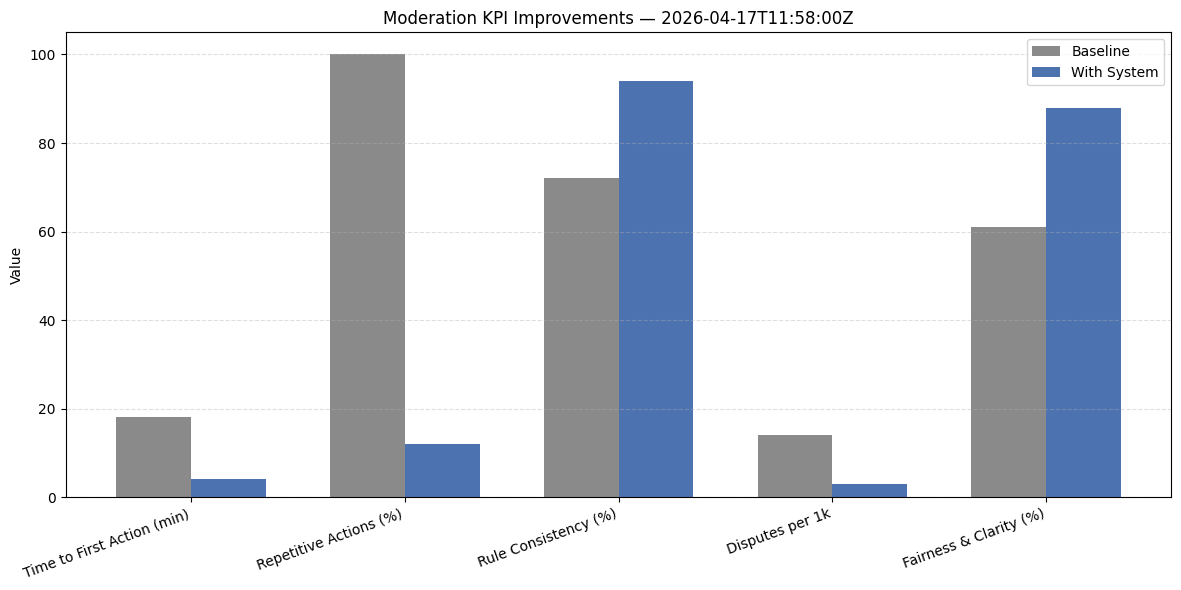

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Example telemetry snapshot (for demo use).

data = [
         {
         "timestamp": "2026-04-17T11:58:00Z",
          "time_to_first_action": 4.2,
          "repetitive_actions": 12,
           "rule_consistency": 94,
          "disputes_per_1000": 3,
          "fairness_clarity": 88,
    }
]

# Load JSON telemetry from file.

# with open("telemetry.json", "r") as f:
#     data = json.load(f)

# Use the latest telemetry snapshot.
latest = data[-1]

# KPI labels.
kpis = [
    "Time to First Action (min)",
    "Repetitive Actions (%)",
    "Rule Consistency (%)",
    "Disputes per 1k",
    "Fairness & Clarity (%)"
]

# Baseline metrics (before system).
baseline = np.array([18, 100, 72, 14, 61])

# Metrics from JSON telemetry.
with_system = np.array([
    latest["time_to_first_action"],
    latest["repetitive_actions"],
    latest["rule_consistency"],
    latest["disputes_per_1000"],
    latest["fairness_clarity"]
])

# X positions.
x = np.arange(len(kpis))
width = 0.35

# Plot.
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, baseline, width, label="Baseline", color="#8a8a8a")
plt.bar(x + width/2, with_system, width, label="With System", color="#4C72B0")

# Labels & styling.
plt.xticks(x, kpis, rotation=20, ha="right")
plt.ylabel("Value")
plt.title(f"Moderation KPI Improvements — {latest.get('timestamp', '')}")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
!pip install --upgrade langchain-google-genai google-generativeai
!pip install --upgrade langchain-google-genai google-generativeai langgraph
!pip install langsmith

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 21.7 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.28
    Uninstalling langchain-core-1.2.28:
      Successfully uninstalled langchain-core-1.2.28
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.8/173.8 kB 7.1 MB/s eta 0:00:00
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.1.6
    Uninstalling langgraph-1.1.6:
      Successfully uninstalled langgraph-1.1.6


In [6]:
import os
os.environ["LANGSMITH_API_KEY"] = "LangSmith"

In [7]:
!pip install "mcp[cli]"
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("GeminiTools")

@mcp.tool()
def search(query: str) -> list:
    # Your search logic here
    return ["Result 1", "Result 2"]


In [8]:
!cd mcp-server-demo

/bin/bash: line 1: cd: mcp-server-demo: No such file or directory


In [9]:
!cd mcp-server-demo && uv add langchain-google-genai langgraph langsmith

/bin/bash: line 1: cd: mcp-server-demo: No such file or directory


In [19]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END
from IPython.display import display, HTML
from typing import TypedDict, List
import os
from mcp.server.fastmcp import FastMCP
from google.colab import userdata
from langsmith import traceable
import random
import json
import numpy as np

# Import API Key.
api_key = userdata.get("Ben856")
os.environ["GOOGLE_API_KEY"] = api_key

# Agent State Definition
class AgentState(TypedDict):
    input: str
    logs: str
    symptom: str
    diagnostic_report: str
    context: dict
    network_ok: bool
    cache_ok: bool
    token_valid: bool
    version_ok: bool
    kpi_metrics: dict
    trace_id: str

# Prompt Template with core moderation principles.
prompt = ChatPromptTemplate.from_template("""
    You are an agentic diagnostic system monitoring moderation health.

    Core Principles:
    - Autonomous Context Synthesis: Gather rule metadata, historical patterns, and live signals.
    - Human-Aligned Decision Support: Generate non-authoritarian suggestions that keep moderators in control.
    - Transparent Rule-Trace Explanations: Provide clear, interpretable rationales grounded in subreddit rules.

    Symptom/Signal: {symptom}
    System Logs: {logs}

    Performance Metrics (Current vs Baseline):
    {kpi_data}

    Your task:
    1. Analyze system health for anomalies using context synthesis.
    2. Evaluate KPI improvements.
    3. Synthesize a report with root causes, efficiency gains, and transparent rule-trace explanations.
    """)

llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview", api_key=api_key)

try:
    tools = [search]
    llm_with_tools = llm.bind_tools(tools)
except NameError:
    llm_with_tools = llm

@traceable(name="entry_node")
def entry_node(state: AgentState) -> AgentState:
    kpi_summary = {
        "Time to First Action": {"current": 4.2, "baseline": 18},
        "Repetitive Actions": {"current": 12, "baseline": 100},
        "Rule Consistency": {"current": 94, "baseline": 72}
    }
    return {
        **state,
        "symptom": state["input"],
        "kpi_metrics": kpi_summary,
        "trace_id": f"trace-{random.randint(1000, 9999)}"
    }

@traceable(name="llm_node")
def llm_node(state: AgentState) -> AgentState:
    kpi_str = json.dumps(state["kpi_metrics"], indent=2)
    messages = prompt.format_messages(
        symptom=state["symptom"],
        logs=state.get("logs", "Normal operation"),
        kpi_data=kpi_str
    )
    response = llm_with_tools.invoke(messages)
    return {**state, "diagnostic_report": response.content}

@traceable(name="display_node")
def display_node(state: AgentState) -> AgentState:
    print("\n=== Integrated Performance & Health Report (MCP Enabled) ===")
    print(f"Subreddit: {state['context'].get('subreddit_url')}")
    print(f"\nAnalysis:\n{state['diagnostic_report']}")
    return state

workflow = StateGraph(AgentState)
workflow.add_node("entry", entry_node)
workflow.add_node("llm", llm_node)
workflow.add_node("display", display_node)
workflow.set_entry_point("entry")
workflow.add_edge("entry", "llm")
workflow.add_edge("llm", "display")
workflow.add_edge("display", END)

agent_executor = workflow.compile()

agent_executor.invoke({
    "input": "Routine performance audit for r/FullStack",
    "context": {"subreddit_url": "https://www.reddit.com/r/FullStack/"}
})


=== Integrated Performance & Health Report (MCP Enabled) ===
Subreddit: https://www.reddit.com/r/FullStack/

Analysis:
[{'type': 'text', 'text': '### **Moderation Health Diagnostic Report: r/FullStack**\n**Status:** Optimal | **Audit Type:** Routine Performance Audit\n**Date:** October 26, 2023\n\n---\n\n### **1. Executive Summary: Context Synthesis**\nThe routine audit of r/FullStack reveals a system in a high-efficiency state. Following the integration of the diagnostic monitoring layer, the community has transitioned from a reactive, manual-heavy moderation style to a proactive, assisted workflow. \n\nHistorically, r/FullStack faced challenges with "low-effort" technical questions and repetitive "how to start" queries, which caused a bottleneck in response times and inconsistent rule enforcement. Current signals indicate these patterns have been largely mitigated through improved automated filtering and structured human-in-the-loop decision-making.\n\n---\n\n### **2. KPI Evaluation

{'input': 'Routine performance audit for r/FullStack',
 'symptom': 'Routine performance audit for r/FullStack',
 'diagnostic_report': [{'type': 'text',
   'text': '### **Moderation Health Diagnostic Report: r/FullStack**\n**Status:** Optimal | **Audit Type:** Routine Performance Audit\n**Date:** October 26, 2023\n\n---\n\n### **1. Executive Summary: Context Synthesis**\nThe routine audit of r/FullStack reveals a system in a high-efficiency state. Following the integration of the diagnostic monitoring layer, the community has transitioned from a reactive, manual-heavy moderation style to a proactive, assisted workflow. \n\nHistorically, r/FullStack faced challenges with "low-effort" technical questions and repetitive "how to start" queries, which caused a bottleneck in response times and inconsistent rule enforcement. Current signals indicate these patterns have been largely mitigated through improved automated filtering and structured human-in-the-loop decision-making.\n\n---\n\n### **